In [28]:
import numpy as np
import pandas as pd

df = pd.read_csv("JC-202603-citibike-tripdata.csv")

In [29]:
# obliczenie czasu przejazdu [min]
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df["time"] = (df["ended_at"] - df["started_at"]).dt.total_seconds()/60

In [30]:
# obliczenie przejechanego dystansu [km]
def dist(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df["distance"] = dist(df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"])

In [35]:
# prędkość w km/min
df["velocity"] = df["distance"]/df["time"]

In [40]:
classic = df[df["rideable_type"] == "classic_bike"]
electric = df[df["rideable_type"] == "electric_bike"]

print("\nPrędkość klasycznego roweru:")
print(classic["velocity"].describe())
print("\nPrędkość elektrycznego roweru: ")
print(electric["velocity"].describe())


Prędkość klasycznego roweru:
count    21642.000000
mean         0.144977
std          0.059858
min          0.000000
25%          0.118843
50%          0.152659
75%          0.183396
max          0.365985
Name: velocity, dtype: float64

Prędkość elektrycznego roweru: 
count    40294.000000
mean         0.212523
std          0.077725
min          0.000000
25%          0.172121
50%          0.217292
75%          0.262052
max          0.500856
Name: velocity, dtype: float64


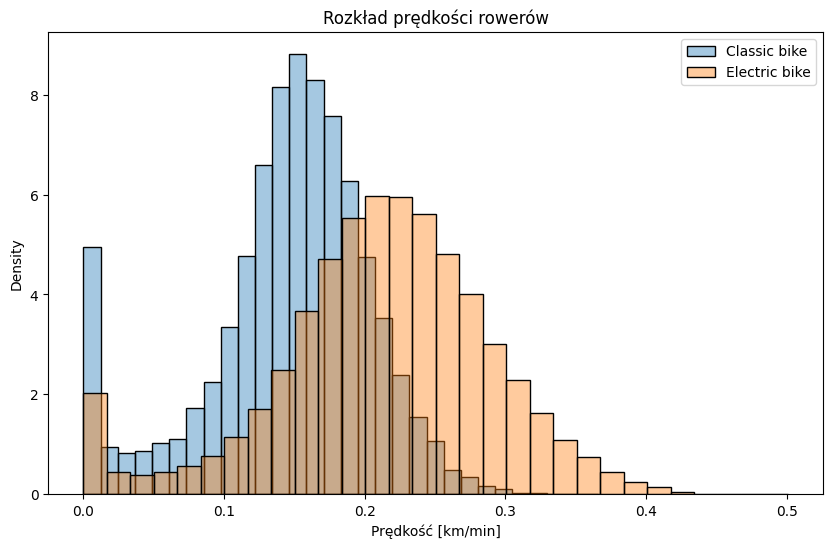

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(classic["velocity"], bins=30, stat="density", alpha=0.4, label="Classic bike")
sns.histplot(electric["velocity"], bins=30, stat="density", alpha=0.4, label="Electric bike")

plt.xlabel("Prędkość [km/min]")
plt.title("Rozkład prędkości rowerów")
plt.legend()

plt.show()